## 01-rnn: Experiment 노트북

### 목표
- RNN, LSTM backbone에서 각각 long-term dependency를 어떻게 처리하는지 성능 비교
- 직접 구현한 Character-level Language Model을 학습 및 평가
- 학습 loss 및 gradient 시각화
- 학습 checkpoint 저장 및 복원 기능 구현

### 1. Import 및 설정

In [45]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [46]:
import math
import copy
import random
from typing import Tuple, Dict, Optional

import torch
import torch.nn as nn
from torch import Tensor
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from model import CharacterLM
from rnn import RNN
from lstm import LSTM

from utils.tokenizer import get_vocab, char_tokenizer

In [47]:
def set_random(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.random.manual_seed(seed)

set_random()

### 2. Dataset 생성

#### Character-level LM Dataset
- 각 시점의 다음 timestep 문자를 예측할 수 있는지를 검증

In [48]:
def encode_text(
        text: str,
        char_to_id: Dict[str, int]
) -> torch.LongTensor:
    """
    문자열 1개가 들어오면, token_id로 변환하여 반환
    """
    token_ids = [char_to_id[c] for c in text]
    token_ids = torch.LongTensor(token_ids)
    return token_ids

text = "hello world"
vocab = get_vocab([text], char_tokenizer)
char_to_id = {c: i for i, c in enumerate(vocab)}
encoded_text = encode_text(text, char_to_id)

assert len(encoded_text) == len(text)
assert encoded_text.dtype == torch.long

In [49]:
def create_lm_dataset(
        token_ids: torch.LongTensor, seq_len: int
    ) -> Tuple[Tensor, Tensor]:
    """
    token_id로 변환된 문자열이 들어오면, seq_len 만큼 데이터셋을 구성
    """
    assert len(token_ids) > seq_len
    windows = token_ids.unfold(0, seq_len+1, 1)

    inputs = windows[:, :-1]
    targets = windows[:, 1:]

    return inputs, targets

inputs, targets = create_lm_dataset(encoded_text, 3)

assert inputs.shape == targets.shape
assert torch.allclose(inputs[:, 1:], targets[:, :-1])

안드레 카파시의 "tiny shakespeare"를 데이터셋으로 활용함

[링크](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt)

In [50]:
with open('data/tiny-shakespeare.txt') as f:
    text = f.read()

text = text[:50_000] # 50,000자만 사용
vocab = get_vocab(corpus=[text], tokenize_fn=char_tokenizer)
char_to_id = {c: i for i, c in enumerate(vocab)}
id_to_char = {i: c for c, i in char_to_id.items()}
token_ids = encode_text(text, char_to_id)

In [51]:
sequence_len = 32
train_len = int(len(text)*0.9)
train_token_ids = token_ids[:train_len]
valid_token_ids = token_ids[train_len:]

assert train_token_ids.dtype == torch.long
assert valid_token_ids.dtype == torch.long
assert len(text) == len(train_token_ids) + len(valid_token_ids)
assert len(train_token_ids) > 32 and len(valid_token_ids) > 32

In [52]:
train_input_ids, train_target_ids = create_lm_dataset(token_ids=train_token_ids, seq_len=sequence_len)
valid_input_ids, valid_target_ids = create_lm_dataset(token_ids=valid_token_ids, seq_len=sequence_len)

assert len(train_input_ids) == len(train_token_ids) - sequence_len
assert len(valid_input_ids) == len(valid_token_ids) - sequence_len

#### DataLoader 구성

In [53]:
train_dataset = TensorDataset(train_input_ids, train_target_ids)
valid_dataset = TensorDataset(valid_input_ids, valid_target_ids)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

### 3. Train

#### 3-1. CharacterLM Train step

In [54]:
def train_step(model, inputs, targets, loss_fn, optimizer, device):
    model.train()
    inputs, targets = inputs.to(device), targets.to(device)
    optimizer.zero_grad()
    logits, _ = model(inputs)
    loss = loss_fn(logits.flatten(0, 1), targets.flatten())
    loss.backward()
    optimizer.step()
    return loss.item()

#### 3-2. Evaluation 함수 제작

In [55]:
def evaluate(model, dataloader, loss_fn, device):
    model.eval()

    total_loss, total_tokens = 0, 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, _ = model(inputs)
            loss = loss_fn(logits.flatten(0, 1), targets.flatten())

            num_tokens = len(targets)
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)

    return avg_loss, ppl

#### 3-3. 전체 Train Loop 함수 제작

In [56]:
def fit(model, train_loader, valid_loader, loss_fn, optimizer, num_epochs, device):
    train_loss, valid_loss, valid_ppl = [], [], []
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = 0
        total_count = 0
        for inputs, targets in train_loader:
            running_loss = train_step(
                model, inputs, targets, loss_fn, optimizer, device
            )
            epoch_loss += running_loss * len(targets)
            total_count += len(targets)
        running_loss = epoch_loss / total_count
        train_loss.append(running_loss)

        eval_loss, eval_ppl = evaluate(model, valid_loader, loss_fn, device)
        valid_loss.append(eval_loss)
        valid_ppl.append(eval_ppl)

        print(f"Epoch {epoch + 1}: Train Loss={running_loss:.4f}, Valid Loss={eval_loss:.4f}, Valid PPL={eval_ppl:.2f}")

    return train_loss, valid_loss, valid_ppl

### 4. RNN vs LSTM 학습 비교
동일한 데이터, seed, embedding/hidden size, optimizer 설정으로 backbone만 바꿔 비교

In [57]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vocab_size = len(vocab)
emb_size = 32
hidden_size = 64
num_epochs = 10

models = {}
for name, backbone_cls in {'RNN': RNN, 'LSTM': LSTM}.items():
    set_random(42)
    models[name] = CharacterLM(
        backbone=backbone_cls(emb_size, hidden_size),
        vocab_size=vocab_size,
        emb_size=emb_size,
        hidden_size=hidden_size,
    ).to(device)

loss_fn = nn.CrossEntropyLoss()
histories = {}
for name, model in models.items():
    print(f'\n{name} training on {device}')
    set_random(42)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    histories[name] = fit(
        model, train_loader, valid_loader, loss_fn, optimizer, num_epochs, device
    )


RNN training on cuda


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: Train Loss=2.3292, Valid Loss=2.0205, Valid PPL=7.54
Epoch 2: Train Loss=1.8856, Valid Loss=1.8840, Valid PPL=6.58
Epoch 3: Train Loss=1.7734, Valid Loss=1.8275, Valid PPL=6.22
Epoch 4: Train Loss=1.7129, Valid Loss=1.8061, Valid PPL=6.09
Epoch 5: Train Loss=1.6740, Valid Loss=1.7904, Valid PPL=5.99
Epoch 6: Train Loss=1.6471, Valid Loss=1.7837, Valid PPL=5.95
Epoch 7: Train Loss=1.6272, Valid Loss=1.7832, Valid PPL=5.95
Epoch 8: Train Loss=1.6113, Valid Loss=1.7855, Valid PPL=5.96
Epoch 9: Train Loss=1.5987, Valid Loss=1.7873, Valid PPL=5.97
Epoch 10: Train Loss=1.5879, Valid Loss=1.7872, Valid PPL=5.97

LSTM training on cuda


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: Train Loss=2.4186, Valid Loss=2.0464, Valid PPL=7.74
Epoch 2: Train Loss=1.9033, Valid Loss=1.8748, Valid PPL=6.52
Epoch 3: Train Loss=1.7607, Valid Loss=1.8027, Valid PPL=6.07
Epoch 4: Train Loss=1.6720, Valid Loss=1.7683, Valid PPL=5.86
Epoch 5: Train Loss=1.6063, Valid Loss=1.7488, Valid PPL=5.75
Epoch 6: Train Loss=1.5568, Valid Loss=1.7444, Valid PPL=5.72
Epoch 7: Train Loss=1.5170, Valid Loss=1.7487, Valid PPL=5.75
Epoch 8: Train Loss=1.4842, Valid Loss=1.7549, Valid PPL=5.78
Epoch 9: Train Loss=1.4565, Valid Loss=1.7656, Valid PPL=5.84
Epoch 10: Train Loss=1.4323, Valid Loss=1.7766, Valid PPL=5.91


**비슷한 수의 파라미터를 갖는 LSTM과 RNN은?**

- Codex피셜 위 설정의 RNN과 거의 비슷한 Param 수를 갖는 LSTM의 hidden size는 31~32
- 2의 배수에 맞춰 `hidden_size=32`로 실험

In [58]:
model = CharacterLM(
    backbone=LSTM(emb_size, 32),
    vocab_size=vocab_size,
    emb_size=emb_size,
    hidden_size=32,
).to(device)

print(f'\nLSTM Train with smiliar param size with RNN')
set_random(42)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
histories['LSTM2'] = fit(
    model, train_loader, valid_loader, loss_fn, optimizer, num_epochs, device
)


LSTM Train with smiliar param size with RNN


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: Train Loss=2.6407, Valid Loss=2.2379, Valid PPL=9.37
Epoch 2: Train Loss=2.1091, Valid Loss=2.0416, Valid PPL=7.70
Epoch 3: Train Loss=1.9609, Valid Loss=1.9601, Valid PPL=7.10
Epoch 4: Train Loss=1.8839, Valid Loss=1.9128, Valid PPL=6.77
Epoch 5: Train Loss=1.8329, Valid Loss=1.8864, Valid PPL=6.60
Epoch 6: Train Loss=1.7973, Valid Loss=1.8652, Valid PPL=6.46
Epoch 7: Train Loss=1.7700, Valid Loss=1.8528, Valid PPL=6.38
Epoch 8: Train Loss=1.7483, Valid Loss=1.8386, Valid PPL=6.29
Epoch 9: Train Loss=1.7301, Valid Loss=1.8361, Valid PPL=6.27
Epoch 10: Train Loss=1.7146, Valid Loss=1.8290, Valid PPL=6.23


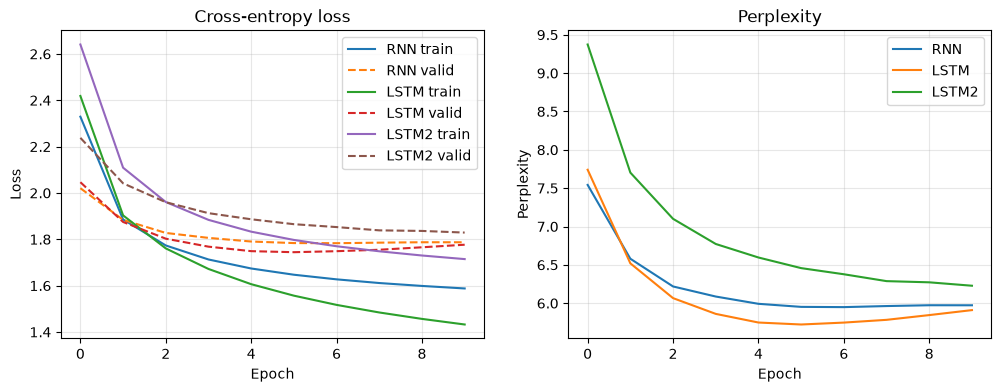

RNN: valid loss=1.7872, perplexity=5.97
LSTM: valid loss=1.7766, perplexity=5.91
LSTM2: valid loss=1.8290, perplexity=6.23


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, (train_loss, valid_loss, valid_ppl) in histories.items():
    axes[0].plot(train_loss, label=f'{name} train')
    axes[0].plot(valid_loss, '--', label=f'{name} valid')
    axes[1].plot(valid_ppl, label=name)

axes[0].set(title='Cross-entropy loss', xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Perplexity', xlabel='Epoch', ylabel='Perplexity')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
plt.show()

for name, (_, valid_loss, valid_ppl) in histories.items():
    print(f'{name}: valid loss={valid_loss[-1]:.4f}, perplexity={valid_ppl[-1]:.2f}')

### 5. RNN vs LSTM 생성 비교

In [60]:
def generate(
        model,
        input_text: str,
        char_to_id: Dict,
        id_to_char: Dict,
        max_new_chars=100,
        temperature=1.0
):
    device = next(model.parameters()).device
    input_token_ids = torch.tensor(
        [char_to_id[c] for c in input_text],
        dtype=torch.long,
        device=device
    )
    generated_text = list(input_text)

    model.eval()
    with torch.no_grad():
        logits, hidden_state = model(input_token_ids)

        for _ in range(max_new_chars):
            next_logits = logits[-1] / temperature

            probabilities = torch.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probabilities, num_samples=1)

            generated_text.append(id_to_char[next_id.item()])
            logits, hidden_state = model(next_id, hidden_state)
    return "".join(generated_text)

In [61]:
prompt = "ROMEO:"

for name, model in models.items():
    set_random(42)

    generated_text = generate(
        model=model,
        input_text=prompt,
        char_to_id=char_to_id,
        id_to_char=id_to_char,
        max_new_chars=300,
        temperature=0.5
    )

    print(f"\n{'=' * 20} {name} {'=' * 20}")
    print(generated_text)


==================== RNN ====================
ROMEO:
IA the lady would smoundess to the wards:
Come.

MARCIUS:
Sield the loor with the wards:
What we are of out of have repetter selmed you, where go me of forth the come and the gopion our honour of the should but the with should the poot the ganers of the renountred.

MARCIUS:
I he cits he with the g

==================== LSTM ====================
ROMEO:
Nor the trustion, that I was done were here?

MARCIUS:
Fire, that sill you the party me.

MARCIUS:
Though his will not is the gods be
preceen against the partions of make my lamp to the competion of the perse at to with senents and the praysition of the rese atterely look on the first preseave
Wher


### 6. Long Sequence에서의 성능

In [62]:
sequence_len = 128
train_len = int(len(text)*0.9)
train_token_ids = token_ids[:train_len]
valid_token_ids = token_ids[train_len:]

train_input_ids, train_target_ids = create_lm_dataset(token_ids=train_token_ids, seq_len=sequence_len)
valid_input_ids, valid_target_ids = create_lm_dataset(token_ids=valid_token_ids, seq_len=sequence_len)

train_dataset = TensorDataset(train_input_ids, train_target_ids)
valid_dataset = TensorDataset(valid_input_ids, valid_target_ids)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

In [63]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vocab_size = len(vocab)
emb_size = 32
hidden_size = 64
num_epochs = 10

models = {}
for name, backbone_cls in {'RNN': RNN, 'LSTM': LSTM}.items():
    set_random(42)
    models[name] = CharacterLM(
        backbone=backbone_cls(emb_size, hidden_size),
        vocab_size=vocab_size,
        emb_size=emb_size,
        hidden_size=hidden_size,
    ).to(device)

loss_fn = nn.CrossEntropyLoss()
histories = {}
for name, model in models.items():
    print(f'\n{name} training on {device}')
    set_random(42)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    histories[name] = fit(
        model, train_loader, valid_loader, loss_fn, optimizer, num_epochs, device
    )


RNN training on cuda


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: Train Loss=2.2635, Valid Loss=1.9381, Valid PPL=6.95
Epoch 2: Train Loss=1.7795, Valid Loss=1.8036, Valid PPL=6.07
Epoch 3: Train Loss=1.6574, Valid Loss=1.7663, Valid PPL=5.85
Epoch 4: Train Loss=1.5940, Valid Loss=1.7705, Valid PPL=5.87
Epoch 5: Train Loss=1.5547, Valid Loss=1.7780, Valid PPL=5.92
Epoch 6: Train Loss=1.5277, Valid Loss=1.7908, Valid PPL=5.99
Epoch 7: Train Loss=1.5074, Valid Loss=1.8081, Valid PPL=6.10
Epoch 8: Train Loss=1.4913, Valid Loss=1.8200, Valid PPL=6.17
Epoch 9: Train Loss=1.4786, Valid Loss=1.8311, Valid PPL=6.24
Epoch 10: Train Loss=1.4679, Valid Loss=1.8452, Valid PPL=6.33

LSTM training on cuda


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: Train Loss=2.3400, Valid Loss=1.9440, Valid PPL=6.99
Epoch 2: Train Loss=1.7732, Valid Loss=1.7780, Valid PPL=5.92
Epoch 3: Train Loss=1.6021, Valid Loss=1.7310, Valid PPL=5.65
Epoch 4: Train Loss=1.4936, Valid Loss=1.7396, Valid PPL=5.69
Epoch 5: Train Loss=1.4131, Valid Loss=1.7659, Valid PPL=5.85
Epoch 6: Train Loss=1.3495, Valid Loss=1.8111, Valid PPL=6.12
Epoch 7: Train Loss=1.2982, Valid Loss=1.8573, Valid PPL=6.41
Epoch 8: Train Loss=1.2565, Valid Loss=1.9040, Valid PPL=6.71
Epoch 9: Train Loss=1.2238, Valid Loss=1.9487, Valid PPL=7.02
Epoch 10: Train Loss=1.1977, Valid Loss=1.9882, Valid PPL=7.30


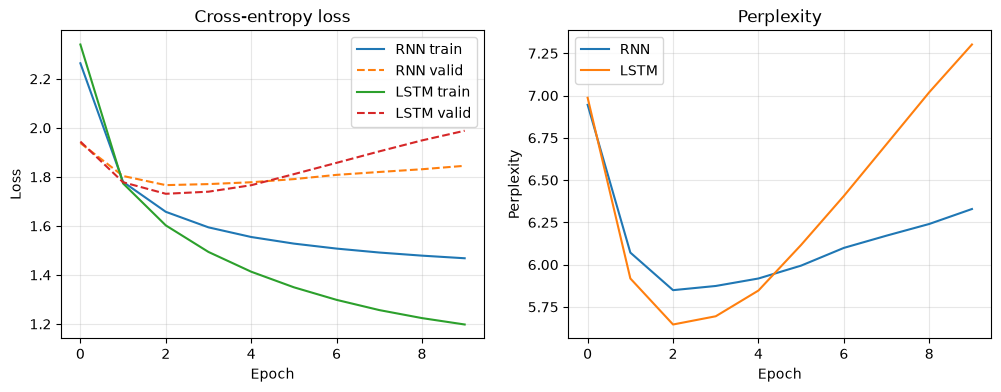

RNN: valid loss=1.8452, perplexity=6.33
LSTM: valid loss=1.9882, perplexity=7.30


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, (train_loss, valid_loss, valid_ppl) in histories.items():
    axes[0].plot(train_loss, label=f'{name} train')
    axes[0].plot(valid_loss, '--', label=f'{name} valid')
    axes[1].plot(valid_ppl, label=name)

axes[0].set(title='Cross-entropy loss', xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Perplexity', xlabel='Epoch', ylabel='Perplexity')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)
plt.show()

for name, (_, valid_loss, valid_ppl) in histories.items():
    print(f'{name}: valid loss={valid_loss[-1]:.4f}, perplexity={valid_ppl[-1]:.2f}')

In [65]:
prompt = "ROMEO:"

for name, model in models.items():
    set_random(42)

    generated_text = generate(
        model=model,
        input_text=prompt,
        char_to_id=char_to_id,
        id_to_char=id_to_char,
        max_new_chars=300,
        temperature=0.5
    )

    print(f"\n{'=' * 20} {name} {'=' * 20}")
    print(generated_text)


==================== RNN ====================
ROMEO:
IA retius her and the preist and the city, if your forth me enemy, in of the propery heart, I were it have be one a state,
And the vire,
The say the city than you are not trues poor out hours, I plire to moor I the gods shall she mutine you ansove done in the belly sond then seeld the poor this a l

==================== LSTM ====================
ROMEO:
Int to be him: he shall friends at warries some the blood
With the very first heart to your his to incorts of the lorse,
The should your seel agther.

LARTIUS:
Then him: he well. I will before the discon.

MENENIUS:
I a shor swords, and may a letter for a man its:
lay, comen to be
the pothing they 


### 7. 모델 구조별 Gradient 변화 분석

In [66]:
def get_grad_norms(model: CharacterLM, inputs: Tensor, targets: Tensor, loss_fn) -> Tensor:
    """
    마지막 timestep의 loss가 각 timestep별 input으로 흘려보내는 gradient 값 구하기

    Args:
        inputs (LongTensor): (batch_size, seq_len) 크기의 입력값
        targets (LongTensor): (batch_size, seq_len) 크기의 정답
    Returns:
        (FloatTensor): (seq_len, ) 크기의 gradient 값 행렬, index가 클수록 마지막 시점에 가까움
    """
    device = next(model.parameters()).device
    inputs = inputs.to(device)
    targets = targets.to(device)

    model = copy.deepcopy(model).double()
    model.zero_grad() # model 내의 모든 gradient를 0으로 초기화
    embedded = model.embedding(inputs) # (B, seq_len, emb_size)
    embedded.retain_grad() # Gradient 사라지는 것 방지 (원래 leaf node가 아닌 tensor의 gradient는 사라짐) 
    output, _ = model.backbone(embedded) # (B, seq_len, hidden_size)
    loss = loss_fn(model.fc(output[:, -1, :]), targets[:, -1])
    loss.backward()
    return embedded.grad.norm(dim=2).mean(dim=0).detach().cpu() # 샘플별로 norm을 계산 후 평균    

In [67]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vocab_size = len(vocab)
emb_size = 32
hidden_size = 64
num_epochs = 10

inputs, targets = next(iter(valid_loader))

grad_norms = {}
for name, backbone_cls in {'RNN': RNN, 'LSTM': LSTM}.items():
    # 학습된 모델이 아닌 초기화 직후 모델을 사용 (backbone 외의 변수를 통제하기 위함)
    set_random(42)
    model = CharacterLM(
        backbone=backbone_cls(emb_size, hidden_size),
        vocab_size=vocab_size,
        emb_size=emb_size,
        hidden_size=hidden_size,
    ).to(device)

    norms = get_grad_norms(model, inputs, targets, nn.CrossEntropyLoss())

    assert norms.shape == (sequence_len,)
    assert torch.isfinite(norms).all()
    # log scale 그래프를 위한 확인: float32였다면 여기서 걸림
    assert (norms > 0).all(), f'{name}: {int((norms == 0).sum())}개 timestep이 0으로 underflow'

    grad_norms[name] = norms
    print(f'{name}: t=0 {norms[0]:.3e} | t={sequence_len // 2} {norms[sequence_len // 2]:.3e} | t={sequence_len - 1} {norms[-1]:.3e}')

RNN: t=0 2.704e-41 | t=64 3.921e-22 | t=127 3.072e-03
LSTM: t=0 1.604e-29 | t=64 7.661e-17 | t=127 8.496e-04


```
RNN: t=0 2.704e-41 | t=64 3.921e-22 | t=127 3.072e-03
LSTM: t=0 1.604e-29 | t=64 7.661e-17 | t=127 8.496e-04
```

맨 뒤 `t=127`에서 발생한 gradient가 특정 `t`에 도착했을 때 얼마나 남아있는지를 확인

RNN은 `t=127 -> t=0`까지 $10^{-38}$ 만큼의 gradient가 decay,
LSTM은 `t=127 -> t=0`까지 $10^{-26}$ 만큼의 gradient가 decay.

즉, RNN은 1step 이전으로 갈 때마다 50%의 gradient만 전달되고, LSTM은 66% 정도의 gradient가 전달됨

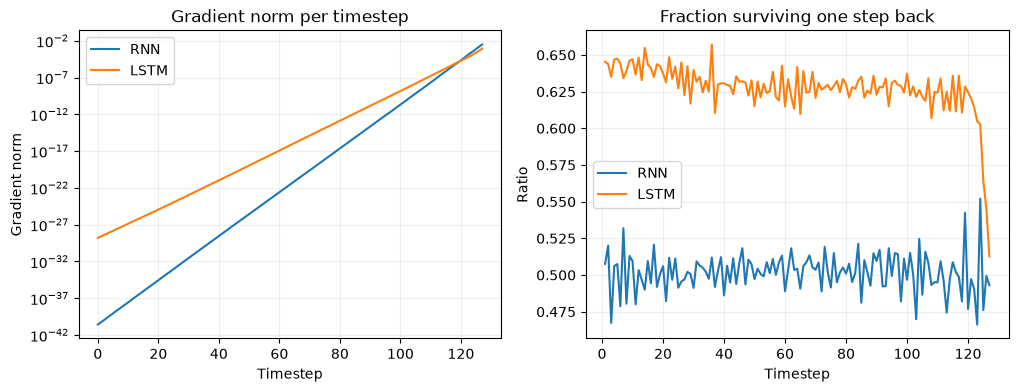

RNN: step당 0.502배 전달
LSTM: step당 0.628배 전달


In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, norms in grad_norms.items():
    axes[0].plot(norms, label=name)
    axes[1].plot(range(1, len(norms)), norms[:-1] / norms[1:], label=name) # 한 step 거슬러 갈 때 남는 비율

axes[0].set(title='Gradient norm per timestep', xlabel='Timestep', ylabel='Gradient norm', yscale='log')
axes[1].set(title='Fraction surviving one step back', xlabel='Timestep', ylabel='Ratio')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.show()

for name, norms in grad_norms.items():
    print(f'{name}: step당 {(norms[:-1] / norms[1:]).mean():.3f}배 전달')

위 그래프와 같이, RNN에 비해서 LSTM이 이전 timestep에 전달하는 gradient 양이 더 많음을 확인할 수 있다.

#### 7-1. Gradient Clipping 전후 비교

In [69]:
# Gradient Clipping 역할을 추가한 새로운 train_step 함수
def train_step(
    model,
    inputs,
    targets,
    loss_fn,
    optimizer: torch.optim.Optimizer,
    device,
    grad_clip: Optional[float] = None
) -> Tuple[float, float]:
    inputs, targets = inputs.to(device), targets.to(device)
    # 1. 모델을 학습 모드로
    model.train()
    # 2. 기존 optimizer의 gradient 초기화
    optimizer.zero_grad()
    # 3. logit 구하기
    logits, _ = model(inputs)
    # 4. loss 구하기
    loss = loss_fn(logits.flatten(0, 1), targets.flatten())
    # 5. backward
    loss.backward()
    # Gradient Clipping
    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(), 
        max_norm=grad_clip if grad_clip is not None else float('inf')
    )
    # 6. optimizer 업데이트
    optimizer.step()

    return loss.item(), grad_norm.item()

In [ ]:
CLIP = 0.2

clip_histories = {}
for label, grad_clip in {'no clip': None, f'clip={CLIP}': CLIP}.items():
    set_random(42)
    model = CharacterLM(
        backbone=RNN(emb_size, hidden_size),
        vocab_size=vocab_size,
        emb_size=emb_size,
        hidden_size=hidden_size,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    norms, valid_loss = [], []
    for epoch in tqdm(range(num_epochs), desc=label):
        for batch_inputs, batch_targets in train_loader:
            _, grad_norm = train_step(model, batch_inputs, batch_targets, loss_fn, optimizer, device, grad_clip)
            norms.append(grad_norm) # clip 이전 값
        valid_loss.append(evaluate(model, valid_loader, loss_fn, device)[0])

    clip_histories[label] = (norms, valid_loss)
    print(f'{label}: best valid={min(valid_loss):.4f} | grad norm 최대={max(norms):.3f}')

# clip이 한 번도 안 걸렸으면 두 실행이 동일해져서 비교가 무의미
assert max(clip_histories['no clip'][0]) > CLIP

no clip:   0%|          | 0/10 [00:00<?, ?it/s]

no clip: best valid=1.7670 | grad norm 최대=0.769


clip=0.2:   0%|          | 0/10 [00:00<?, ?it/s]

clip=0.2: best valid=1.7917 | grad norm 최대=0.859


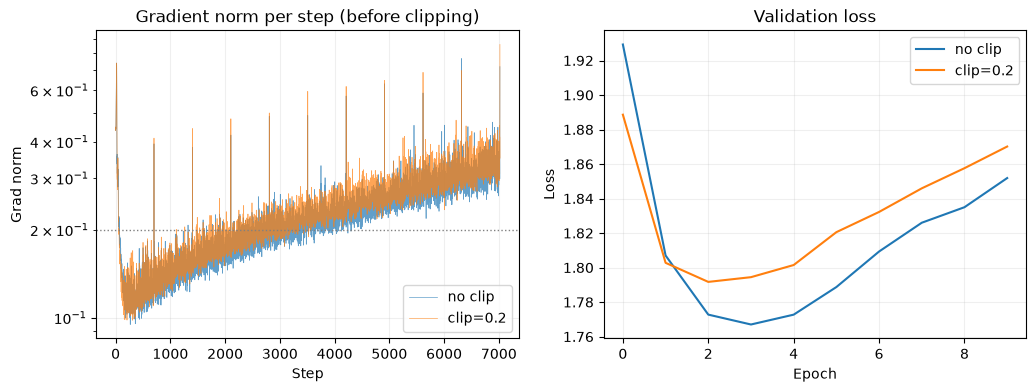

no clip: 4052/7020 step (57.7%)이 clip 기준을 넘음
clip=0.2: 4411/7020 step (62.8%)이 clip 기준을 넘음


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, (norms, valid_loss) in clip_histories.items():
    axes[0].plot(norms, lw=0.5, alpha=0.7, label=label)
    axes[1].plot(valid_loss, label=label)

axes[0].axhline(CLIP, color='gray', ls=':', lw=1)
axes[0].set(title='Gradient norm per step (before clipping)', xlabel='Step', ylabel='Grad norm', yscale='log')
axes[1].set(title='Validation loss', xlabel='Epoch', ylabel='Loss')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.show()

for label, (norms, _) in clip_histories.items():
    over = sum(n > CLIP for n in norms)
    print(f'{label}: {over}/{len(norms)} step ({over / len(norms):.1%})이 clip 기준을 넘음')

### 8. 학습 Checkpoint 저장 및 로드

모델을 저장하고 1) 이후에 불러와 학습을 재개하거나, 2) 이후에 추론을 수행하기 위해서는 Checkpoint 기능을 이용하면 된다.

해당 기능을 이용하기 위한 몇 가지 주의사항은 다음과 같다:
- 모델의 내부 파라미터를 저장해 경로와는 무관하게 같은 모델 구조이면 저장하고 불러오기 용이하도록 한다.
- 만약, 모델만 저장하게 된다면? Adam과 같은 optimizer는 파라미터마다 특정 값을 가지고 있는데 이를 버리게 되면 안된다.
- Vocab 또한 달라지는 것을 방지해야 한다.

In [72]:
def save_checkpoint(
        path: str,
        model: nn.Module,
        vocab: list,
        optimizer: torch.optim.Optimizer,
        epoch: int,
        history: Dict[str, list],
        config: Dict
) -> None:
    """
    모델의 학습 상태 및 optimizer, history 등을 재개 가능한 형태로 저장
    """
    # 저장 위치 폴더 생성
    dirname = os.path.dirname(path)
    if dirname:
        os.makedirs(dirname, exist_ok=True)

    # 저장할 내용 조립
    save_data = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'vocab': vocab,
        'history': history,
        'config': config
    }

    # 저장
    torch.save(save_data, path)


def load_checkpoint(
        path: str,
        model: nn.Module,
        optimizer: torch.optim.Optimizer | None = None,
) -> Dict:
    """
    체크포인트를 model(과 optimizer)에 복원하고, 나머지 메타데이터를 반환

    Returns:
        (Dict): epoch, history, config, vocab 등 가중치를 제외한 정보
    """
    # 불러오기
    checkpoint = torch.load(path, map_location='cpu')

    # 모델 state_dict 덮어쓰기
    model.load_state_dict(checkpoint['model_state_dict'])

    # Optimizer state_dict 덮어쓰기
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    del checkpoint['model_state_dict']
    del checkpoint['optimizer_state_dict']

    return checkpoint

In [73]:
config = {'backbone': 'LSTM', 'vocab_size': vocab_size, 'emb_size': emb_size, 'hidden_size': hidden_size}
save_checkpoint('checkpoints/lstm.pt', models['LSTM'], vocab, optimizer, num_epochs, histories['LSTM'], config)

models['LSTM'].eval()
with torch.no_grad():
    before, _ = models['LSTM'](inputs.to(device))

set_random(0) # 다른 seed로 껍데기를 만들어야 복원 여부를 실제로 검증할 수 있음
restored = CharacterLM(
    backbone=LSTM(emb_size, hidden_size),
    vocab_size=vocab_size,
    emb_size=emb_size,
    hidden_size=hidden_size,
).to(device)
meta = load_checkpoint('checkpoints/lstm.pt', restored)

restored.eval()
with torch.no_grad():
    after, _ = restored(inputs.to(device))

torch.testing.assert_close(before, after)
assert meta['vocab'] == vocab

print(f"복원 성공: epoch={meta['epoch']}, config={meta['config']}")

복원 성공: epoch=10, config={'backbone': 'LSTM', 'vocab_size': 59, 'emb_size': 32, 'hidden_size': 64}


### 9. 정리

#### 예상과 실제
- 예상: 짧은 Sequence에서 RNN/LSTM 모두 학습이 잘 될것
    - 실제: 길이 32인 sequence에서 Valid loss = RNN: 1.78, LSTM: 1.74
- 예상: 긴 Sequence에서 Vanila RNN의 성능이 떨어질 것
    - 실제: 길이 128인 sequence에서 Valid loss = RNN: 1.76, LSTM: 1.73 -> 둘 다 오히려 개선
- 예상: 긴 Sequence에서 RNN보다 LSTM의 gradient가 더 안정적일 것
    - 실제: 길이 128에서 t=0 기준 약 6×10¹¹배 차이

#### 성능이 떨어지지 않은 이유?
RNN이 더 긴 sequence length에서 무너지지 않은 이유는?

- 실제로 두 모델이 참고하는 문맥은 앞의 7~10글자 정도 (gradient가 1%까지 줄어드는 거리)
- Task 자체가 장기의존성을 필요로 하지 않는 Task이므로 loss에는 영향이 없었다.
- 다만, Gradient에서는 긴 sequence에서 RNN의 vanishing을 확인

#### AI Review: forget gate bias 실험

LSTM의 forget gate bias를 1.0/3.0으로 초기화해 gradient 감쇠를 인위적으로 없애봤다.

- `f_bias=3.0`에서 감쇠가 사실상 사라짐 (t=0 gradient가 기본 대비 6×10²⁵배)
- 그런데 best valid는 1.7310 → 1.7234. **10²⁵배를 흘려도 loss는 0.008 움직였다**
- 대신 과적합이 크게 줄었다 (final valid 1.9877 → 1.7781). 수렴이 느려져 10 epoch 안에 과적합할 시간이 없었던 것으로 보임|

#### 다음 질문 / 추후 찾아볼 것
1. 장기의존성이 실제로 필요한 Task에서 RNN/LSTM의 loss 차이가 드러날지
2. 학습이 진행되면서 gradient norm이 커지는 이유는? Clipping을 더 효과적으로 사용하려면 어떤 학습 설정에서 학습을 해야 할까?
3. 앞선 Sequence Length 128 실험에서 실제 모델이 참고하는 문맥은 앞의 7~10글자 정도. 만약 더 이전 대화의 문맥을 파악해야 하는 Task에서는?
